# K-Nearest-Neighbors

👇 `data` klasöründe bulunan `houses_clean.csv` dataset'ini yükleyin  
Veya doğrudan bu URL'den yükleyebilirsiniz: [https://d32aokrjazspmn.cloudfront.net/materials/ML_Houses_clean.csv](https://d32aokrjazspmn.cloudfront.net/materials/ML_Houses_clean.csv).  

Dataset açıklaması dataset-description.md dosyasında bulunabilir.

In [4]:
import pandas as pd
df = pd.read_csv("/Users/aybukealtuntas/S16D1-S-data-knn/data/ML_Houses_clean.csv")
df

,GrLivArea,BedroomAbvGr,KitchenAbvGr,OverallCond,CentralAir,SalePrice
0,0.380070,0.375,0.333333,0.500,1,208500
1,-0.312090,0.375,0.333333,0.875,1,181500
2,0.497489,0.375,0.333333,0.500,1,223500
3,0.390885,0.375,0.333333,0.500,1,140000
4,1.134029,0.500,0.333333,0.500,1,250000
...,...,...,...,...,...,...
1455,0.282735,0.375,0.333333,0.500,1,175000
1456,0.940904,0.375,0.333333,0.625,1,210000
1457,1.353418,0.500,0.333333,1.000,1,266500
1458,-0.596369,0.250,0.333333,0.625,1,142125


💡 Çoğu özellik zaten önceden işlenmiştir (normalizasyonla ölçeklendirilmiştir), tıpkı Veri Hazırlama gününde yaptığınız gibi  

💡 Bir özellik olan `GrLiveArea` normalleştirilmemiştir. Daha sonra normalizasyonunun model performansımız üzerindeki etkisini görmek için bu şekilde tutuyoruz  

👇 Bunu tanımlayıcı istatistiklerle kolayca görebilirsiniz, min ve max değerlerine bakın

In [5]:
df.describe()

,GrLivArea,BedroomAbvGr,KitchenAbvGr,OverallCond,CentralAir,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,0.078410,0.358305,0.348858,0.571918,0.934932,180921.195890
std,0.813952,0.101972,0.073446,0.139100,0.246731,79442.502883
min,-2.263422,0.000000,0.000000,0.000000,0.000000,34900.000000
25%,-0.516802,0.250000,0.333333,0.500000,1.000000,129975.000000
50%,0.000000,0.375000,0.333333,0.500000,1.000000,163000.000000
75%,0.483198,0.375000,0.333333,0.625000,1.000000,214000.000000
max,6.455002,1.000000,1.000000,1.000000,1.000000,755000.000000


# Varsayılan KNN

🎯 Görev, tüm özelliklerle evlerin fiyatını (`SalePrice`) tahmin etmektir.

👇 Böyle bir görevde varsayılan [KNNRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html)'ı değerlendirmek için çapraz doğrulama kullanın.  
❓ `SalePrice`'taki varyansın özellikler tarafından açıklanan oranı nedir?  
Cevabınızı `base_knn_score` adlı bir değişkende saklayın.

<details>
<summary> 💡 İpucu </summary>
    <br>
    ℹ️ Bağımlı değişkendeki varyansın bağımsız değişkenler tarafından açıklanan oranı R2 skoru'dur.
</details>

In [14]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score

X = df[["GrLivArea","BedroomAbvGr","KitchenAbvGr","OverallCond","CentralAir"]]
y = df["SalePrice"]
# 1. Varsayılan KNN modelini tanımlayalım
knn_model = KNeighborsRegressor()

# 2. Çapraz doğrulama uygulayalım
# scoring='r2' varsayılan varyans açıklama oranını döndürür
cv_scores = cross_val_score(knn_model, X, y, cv=5, scoring='r2')

# 3. Ortalama skoru değişkene atayalım
base_knn_score = cv_scores.mean()

print(f"SalePrice varyansının açıklanma oranı (R²): {base_knn_score:.4f}")

SalePrice varyansının açıklanma oranı (R²): 0.6086


### 🧪 Kodunuzu kontrol edin

In [7]:
from nbresult import ChallengeResult

result = ChallengeResult('default_score',
                         score = base_knn_score)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/aybukealtuntas/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/aybukealtuntas/S16D1-S-data-knn/tests
plugins: dash-4.0.0, anyio-4.8.0, typeguard-4.4.2
collecting ... collected 1 item

test_default_score.py::TestDefault_score::test_score PASSED              [100%]

============================== 1 passed in 0.18s ===============================


💯 You can commit your code:

git add tests/default_score.pickle

git commit -m 'Completed default_score step'

git push origin master



# Ölçek duyarlılığı

KNN'ler ve mesafe tabanlı algoritmalar özelliklerin ölçeğine son derece duyarlı olabilir. 

👇 Özellik kümesini **tam ortak aralık** içinde yeniden ölçeklendirin ve `X_rescaled` adlı bir değişken altında kaydedin  
Ardından, yeniden ölçeklendirilmiş özellikler üzerinde bir modeli değerlendirin ve skorunu `rescaled_score` değişken adı altında kaydedin.

<details>
<summary> 💡 İpucu </summary>
    
`MinMaxScaler()`

Sadece `GrLiveArea`'nın normalleştirilmesi gerekmesine rağmen, tüm özelliklerinizde MinMaxScaler kullanmak sorun değil  
    
Gerçekten de, Min-Max Ölçeklendirme [idempotent](https://en.wikipedia.org/wiki/Idempotence) bir dönüşümdür: eğer $X_{max}=1$ ve $X_{min}=0$ ise, o zaman $X = \frac{X - X_{min}}{X_{max} - X_{min}}$
</details>

In [15]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import MinMaxScaler

# 1. MinMaxScaler'ı tanımlayıp tüm özelliklere (X) uygulayalım
scaler = MinMaxScaler()
X_rescaled = scaler.fit_transform(X)

# 2. Modeli tanımlayalım
knn_model = KNeighborsRegressor()

# 3. Ölçeklenmiş veri ile çapraz doğrulama yapalım
# scoring='r2' varyansın açıklanan oranını (R-squared) verir
rescaled_score = cross_val_score(knn_model, X_rescaled, y, cv=5, scoring='r2')

# 4. Sonucu değişkene atayalım
rescaled_score = rescaled_score.mean()

print(f"Ölçeklendirilmiş KNN Skoru (R²): {rescaled_score:.4f}")

Ölçeklendirilmiş KNN Skoru (R²): 0.6497


👉 R2 skoru artmış olmalı!

💡 Mesafe tabanlı algoritmaları modellerken özelliklerin tam ortak aralıkta olması tercih edilir.  
Ancak, her zaman daha iyi bir skor garanti etmez.  
Bu bir deneme yanılma sürecidir.

### 🧪 Kodunuzu kontrol edin

In [16]:
from nbresult import ChallengeResult

result = ChallengeResult('scale_sensitivity',
                         base_score = base_knn_score,
                         rescaled_features = X_rescaled,
                         rescaled_score = rescaled_score)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/aybukealtuntas/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/aybukealtuntas/S16D1-S-data-knn/tests
plugins: dash-4.0.0, anyio-4.8.0, typeguard-4.4.2
collecting ... collected 2 items

test_scale_sensitivity.py::TestScale_sensitivity::test_rescaled_features PASSED [ 50%]
test_scale_sensitivity.py::TestScale_sensitivity::test_score_inscrease PASSED [100%]

============================== 2 passed in 0.16s ===============================


💯 You can commit your code:

git add tests/scale_sensitivity.pickle

git commit -m 'Completed scale_sensitivity step'

git push origin master



# $k$ Optimizasyonu

👇 Yeniden ölçeklendirilmiş özellikler üzerinde bir KNNRegressor'ın K parametresini (`n_neighbors` parametresini kullanarak) ince ayarlayın. K 1'den 25'e kadar arttıkça skorun evrimini çizin.

In [18]:
scores={}
for i in range(1,25):
    knn_model = KNeighborsRegressor(n_neighbors=i)
    score = cross_val_score(knn_model, X_rescaled, y, cv=5, scoring='r2')
    score = score.mean()
    scores[i] = score
scores

{1: 0.48643978631100937,
 2: 0.6267417341431845,
 3: 0.6361131968558427,
 4: 0.6424218015704231,
 5: 0.6496841000103444,
 6: 0.6522754507028157,
 7: 0.652839334921044,
 8: 0.6519261906963425,
 9: 0.6554831582849612,
 10: 0.654649718853763,
 11: 0.6571094901627201,
 12: 0.6547622648461493,
 13: 0.6559293474292767,
 14: 0.6531144861475239,
 15: 0.6506644507844749,
 16: 0.6510587444798077,
 17: 0.648992334002443,
 18: 0.6468309968654011,
 19: 0.6434622558331211,
 20: 0.6426314978289545,
 21: 0.641230517625335,
 22: 0.6396124217700394,
 23: 0.6379363773825212,
 24: 0.6360964020468971}

❓ K'nın hangi değeri en iyi performansı üretir? Cevabınızı `best_k` değişken adı altında kaydedin.

In [24]:
best_score = 0
best_k = 0
for key,value in scores.items():
    if scores[key] > best_score:
        best_score = scores[key]
        best_k = key
best_k

11

<details>
<summary> 👉 Çözüm 👈</summary>
    
Grafiğinize bakarak, skorun k = 5 civarında artmayı durdurduğunu ve maksimum skorun k = 11 için ulaşıldığını görmelisiniz.

</details>

❓ $k$ < 5 değerleri için modelin kötü performansını nasıl yorumluyorsunuz?

<details>
<summary> 👉 Çözüm 👈</summary>
    
K çok küçük olduğunda, model eğitim kümesine aşırı uyum gösterme eğiliminde olacaktır. İyi genelleştirebilmek için çok az noktaya odaklanacaktır. K'yı artırmak modele tahminlerini dayandıracağı daha fazla örnek verecektir.

</details>

### 🧪 Kodunuzu kontrol edin

In [25]:
from nbresult import ChallengeResult

result = ChallengeResult('optimal_k',
                         optimal_k = best_k)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/aybukealtuntas/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/aybukealtuntas/S16D1-S-data-knn/tests
plugins: dash-4.0.0, anyio-4.8.0, typeguard-4.4.2
collecting ... collected 1 item

test_optimal_k.py::TestOptimal_k::test_optimal_K_around_10 PASSED        [100%]

============================== 1 passed in 0.01s ===============================


💯 You can commit your code:

git add tests/optimal_k.pickle

git commit -m 'Completed optimal_k step'

git push origin master



# KNN'de Aşırı Uyum

💡 KNN'lerin K parametresi çok küçük olduğunda, eğitim kümesine aşırı uyum gösterme ve iyi genelleştirememe riski vardır. 

👇 K=2 parametreli bir KNN'in öğrenme eğrilerini çizin.

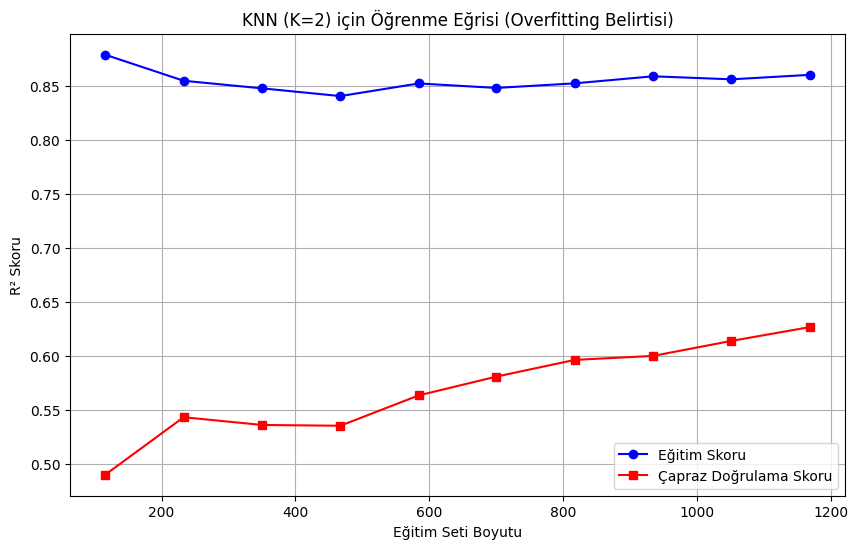

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.neighbors import KNeighborsRegressor

# 1. K=2 olan modelimizi tanımlayalım
knn_model = KNeighborsRegressor(n_neighbors=2)

# 2. Öğrenme eğrisi verilerini hesaplayalım
train_sizes, train_scores, test_scores = learning_curve(
    knn_model, X_rescaled, y, cv=5, scoring='r2', 
    train_sizes=np.linspace(0.1, 1.0, 10)
)

# 3. Skorların ortalamasını alalım
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

# 4. Görselleştirme
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Eğitim Skoru', color='blue', marker='o')
plt.plot(train_sizes, test_mean, label='Çapraz Doğrulama Skoru', color='red', marker='s')

plt.title('KNN (K=2) için Öğrenme Eğrisi (Overfitting Belirtisi)')
plt.xlabel('Eğitim Seti Boyutu')
plt.ylabel('R² Skoru')
plt.legend()
plt.grid(True)
plt.show()

👉 Yüksek eğitim skoru ama düşük test skoru gözlemlemelisiniz. ⚠️ Aşırı uyum uyarısı ⚠️ Bu çok düşük K parametresinden kaynaklanır.

# İdeal K

👇 Bu sefer, "$k$ Optimizasyonu" bölümünde bulduğunuz ideal K değeri için öğrenme eğrilerini çizin.

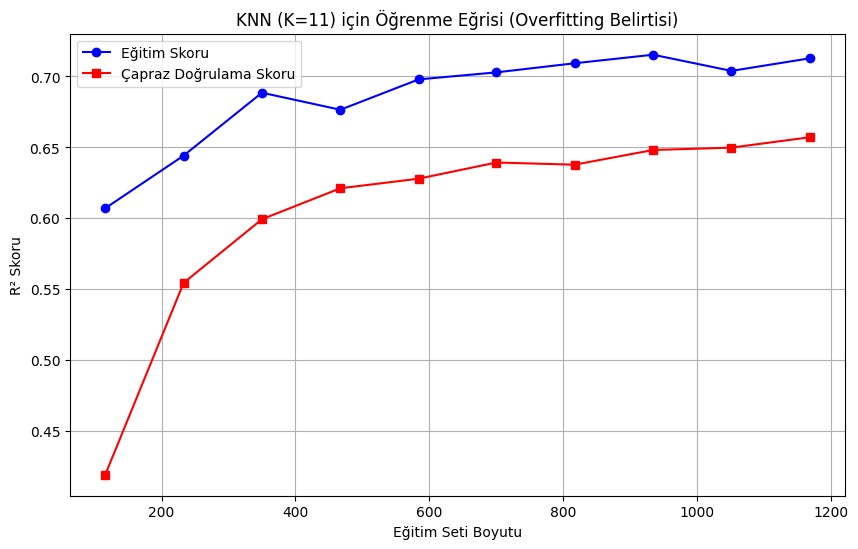

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.neighbors import KNeighborsRegressor


knn_model = KNeighborsRegressor(n_neighbors=best_k)

# 2. Öğrenme eğrisi verilerini hesaplayalım
train_sizes, train_scores, test_scores = learning_curve(
    knn_model, X_rescaled, y, cv=5, scoring='r2', 
    train_sizes=np.linspace(0.1, 1.0, 10)
)

# 3. Skorların ortalamasını alalım
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

# 4. Görselleştirme
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Eğitim Skoru', color='blue', marker='o')
plt.plot(train_sizes, test_mean, label='Çapraz Doğrulama Skoru', color='red', marker='s')

plt.title('KNN (K=11) için Öğrenme Eğrisi (Overfitting Belirtisi)')
plt.xlabel('Eğitim Seti Boyutu')
plt.ylabel('R² Skoru')
plt.legend()
plt.grid(True)
plt.show()

👉 Eğriler yakınsamaya yakın olmalı, bu da modelin daha az aşırı uyum gösterdiğini ve daha iyi genelleştirdiğini gösterir.

💡 KNN modelleriyle modelleme yaparken hatırlanması gereken iki temel unsur vardır:  
    1. Mesafe tabanlı algoritmalar özelliklerin ölçeğine son derece duyarlıdır  
    2. K ayarlanmalıdır: performans, genelleştirme ve aşırı uyum arasındaki dengeyi kontrol eder

❓ Optimize edilmiş KNN modelinin gerçek fiyat ile tahmin edilen fiyat arasındaki ortalama fark nedir? Cevabınızı hesaplayın ve `price_error` değişken adı altında kaydedin

<details>
<summary> 💡 İpucu </summary>
    
Hesaplamanız gereken metrik **Negatif Ortalama Mutlak Hata (MAE)**'dır.

</details>

In [28]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_absolute_error

# 1. En iyi K değerine sahip modeli tanımlayalım
optimized_knn = KNeighborsRegressor(n_neighbors=best_k)

# 2. Çapraz doğrulama ile tahminleri alalım
# cross_val_predict, her bir veri noktası için 'görmediği' bir katlamadan tahmin üretir
y_pred = cross_val_predict(optimized_knn, X_rescaled, y, cv=5)

# 3. Ortalama hatayı (MAE) hesaplayalım
price_error = mean_absolute_error(y, y_pred)

print(f"Optimize edilmiş KNN modelinin ortalama fiyat hatası: {price_error:.2f}")

Optimize edilmiş KNN modelinin ortalama fiyat hatası: 30819.02


### 🧪 Kodunuzu kontrol edin

In [29]:
from nbresult import ChallengeResult

result = ChallengeResult('price_error',
                         error = price_error)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/aybukealtuntas/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/aybukealtuntas/S16D1-S-data-knn/tests
plugins: dash-4.0.0, anyio-4.8.0, typeguard-4.4.2
collecting ... collected 1 item

test_price_error.py::TestPrice_error::test_price_error_range PASSED      [100%]

============================== 1 passed in 0.01s ===============================


💯 You can commit your code:

git add tests/price_error.pickle

git commit -m 'Completed price_error step'

git push origin master



# Model Seçimi

❓ Ev fiyatlarını tahmin etme görevini gerçekleştirmek için bu iki modelden hangisini seçersiniz:
- Az önce ayarladığınız KNN modeli
- Bir Linear Regression modeli

Cevabınızı "KNN" veya "LinearReg" olarak `best_model` değişken adı altında string olarak kaydedin.

<details>
<summary> 💡 İpucu </summary>
    
Hangisini seçeceğinize karar vermek için, aynı görev üzerinde bir Linear Regression skorunu değerlendirmeniz ve KNN'in skoruyla karşılaştırmanız gerekecek. Aynı metrikleri karşılaştırdığınızdan emin olun!!

</details>

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

# Modeli tanımlayalım
model = LinearRegression()

# Ölçeklenmiş veri ile çapraz doğrulama yapalım
# scoring='r2' varyansın açıklanan oranını (R-squared) verir
linear_score = cross_val_score(model, X_rescaled, y, cv=5, scoring='r2')

# Sonucu değişkene atayalım 
linear_score = linear_score.mean()

print(f"linearregression Skoru (R²): {linear_score:.4f}")

linearregression Skoru (R²): 0.5945


In [34]:
best_model = "KNN"

💡 Her iki modelin metriklerini karşılaştırdığınızda, KNN modeli Linear Regression'ı geçmelidir. Bu, verideki doğrusal olmayan kalıpları yakalama yeteneğinden kaynaklanabilir.

### 🧪 Kodunuzu kontrol edin

In [35]:
from nbresult import ChallengeResult

result = ChallengeResult('best_model',
                         model = best_model)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/aybukealtuntas/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/aybukealtuntas/S16D1-S-data-knn/tests
plugins: dash-4.0.0, anyio-4.8.0, typeguard-4.4.2
collecting ... collected 1 item

test_best_model.py::TestBest_model::test_best_model PASSED               [100%]

============================== 1 passed in 0.01s ===============================


💯 You can commit your code:

git add tests/best_model.pickle

git commit -m 'Completed best_model step'

git push origin master



# 🏁